In [29]:
import os
import yaml
import logging
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import matplotlib.ticker as mtick
from sklearn.metrics import precision_recall_curve, classification_report

from pyspark.sql.functions import col, udf
from pyspark.sql.types import FloatType
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.classification import GBTClassificationModel

from utils.spark_session import get_spark_session

from sklearn.metrics import classification_report
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import numpy as np
from sklearn.metrics import f1_score, classification_report

spark = get_spark_session("08-evaluate-pipeline-artifacts")

In [30]:
test_path = os.path.join("..", "data", "train_test", "test.parquet")
config_path = os.path.join("..", "src", "config", "feature_config.yaml")
features_selected_path = os.path.join("..", "src", "features", "selected", "features_selected.yaml")
model_path = os.path.join("..", "models", "final_gbt_model")

In [31]:
# Load files
df = spark.read.parquet(test_path)
with open(config_path, 'r') as f:
    feature_config = yaml.safe_load(f)
with open(features_selected_path, 'r') as f:
    selected_yaml = yaml.safe_load(f)


In [32]:
# Define target and features
target_col = [k for k, v in feature_config.items() if isinstance(v, dict) and v.get("target")][0]
selected_features = selected_yaml.get("support_random_forest", [])
available_cols = [f.name for f in df.schema.fields]
feature_cols = [f for f in selected_features if f in available_cols]

In [33]:
assembler = VectorAssembler(inputCols=feature_cols, outputCol="features")
df_test = assembler.transform(df.select(*(feature_cols + [target_col]))).select("features", col(target_col).alias("label"))

df_test.show()

+--------------------+-----+
|            features|label|
+--------------------+-----+
|[3.13043478260869...|    0|
|[1.36956521739130...|    0|
|[8.54347826086956...|    0|
|[1.82903225806451...|    0|
|[1.12580645161290...|    0|
|[0.006,0.006,186....|    0|
|[1.45806451612903...|    0|
|[3.00000000000000...|    0|
|[2.09032258064516...|    0|
|[2.76774193548387...|    0|
|[2.39354838709677...|    0|
|[1.92682926829268...|    0|
|[1.04878048780487...|    0|
|[3.43902439024390...|    0|
|[2.69268292682926...|    1|
|[2.26829268292682...|    0|
|[3.53658536585365...|    0|
|[3.65853658536585...|    0|
|[4.53658536585365...|    0|
|[4.63414634146341...|    0|
+--------------------+-----+
only showing top 20 rows



In [34]:
# Load model and fit model

model = GBTClassificationModel.load(model_path)
predictions = model.transform(df_test)

In [35]:
extract_prob_1 = udf(lambda v: float(v[1]), FloatType())
predictions = predictions.withColumn("prob_1", extract_prob_1(col("probability")))

In [36]:
pred_pd = predictions.select("prob_1", "prediction", "label").toPandas()
probs = pred_pd["prob_1"].values
true_labels = pred_pd["label"].values

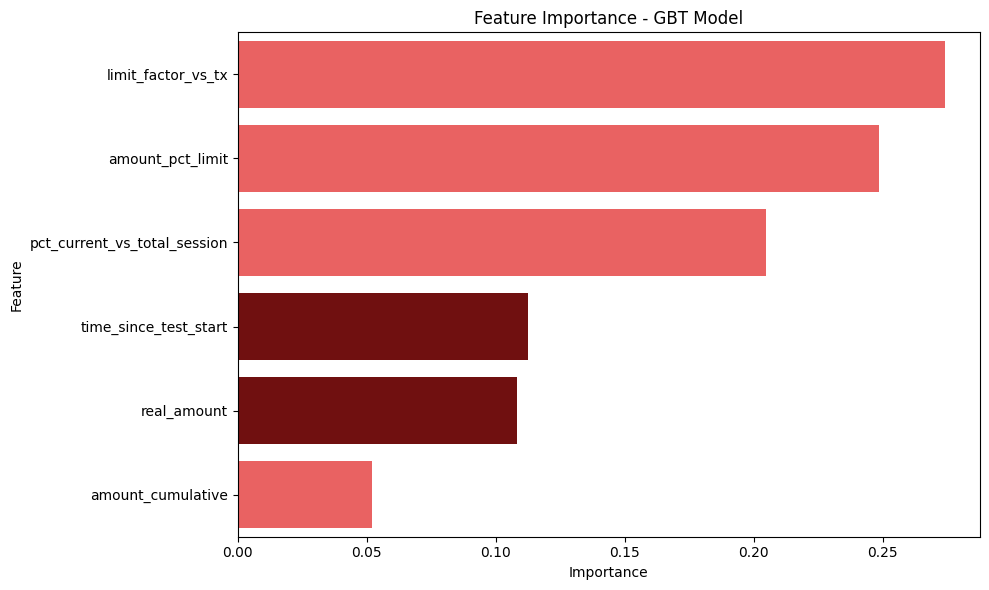

In [37]:
# Load trained model and extract importances
importances = model.featureImportances.toArray()
final_features = selected_features[:len(importances)]

# Assemble features for test set
assembler = VectorAssembler(inputCols=final_features, outputCol="features")
df_test = assembler.transform(df.select(*(final_features + [target_col])))
df_test = df_test.select("features", col(target_col).alias("label"))

# Define engineered features manually based on your YAML
engineered_features = [
    'real_amount_per_limit',
    'n_transactions_so_far',
    'amount_cumulative',
    'n_conversions_so_far',
    'pct_current_vs_total_session',
    'amount_pct_limit',
    'limit_factor_vs_tx'
]

# Build importance DataFrame
feature_importance_df = pd.DataFrame({
    'feature': final_features,
    'importance': importances
})

# Filter out zero-importance features
feature_importance_df = feature_importance_df[feature_importance_df['importance'] > 0]

# Assign color by type
feature_importance_df['color'] = feature_importance_df['feature'].apply(
    lambda x: '#ff4c4c' if x in engineered_features else '#800000'  # light red vs dark red
)

# Sort
feature_importance_df = feature_importance_df.sort_values(by='importance', ascending=False)

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(
    x='importance',
    y='feature',
    data=feature_importance_df,
    palette=feature_importance_df['color'].tolist()
)
plt.title('Feature Importance - GBT Model')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()


In [38]:
# Calculate total importance of engineered vs original features
engineered_total = feature_importance_df[
    feature_importance_df['feature'].isin(engineered_features)
]['importance'].sum()

overall_total = feature_importance_df['importance'].sum()

engineered_percentage = engineered_total / overall_total * 100
print(f"Engineered features account for {engineered_percentage:.2f}% of total importance.")


Engineered features account for 77.91% of total importance.


In [44]:
def get_summary_by_quantile(df, score_col='score', target_col='label', n_bins=10):
    df = df.copy()

    # Create score bins (e.g., 0–99, 100–199, ..., 900–1000)
    bin_edges = list(range(0, 1001, int(1000 / n_bins)))
    df['quantile'] = pd.cut(df[score_col], bins=bin_edges, labels=False, include_lowest=True)

    # Ensure highest scores fall in the highest decile (Decile 10)
    df['quantile'] = df['quantile'] + 1  # Make quantiles 1-based

    # Define expected quantile labels
    quantiles = list(range(1, n_bins + 1))

    # Recall per quantile
    recall_per_quantile = (
        df.groupby('quantile')[target_col].sum() / df[target_col].sum()
    ).reindex(quantiles, fill_value=0).reset_index()
    recall_per_quantile = recall_per_quantile.rename(columns={target_col: 'recall'})

    # Number of positive cases (e.g., completed promotions) per quantile
    promo_items = (
        df[df[target_col] == 1]
        .groupby('quantile')
        .size()
        .reindex(quantiles, fill_value=0)
        .reset_index(name='promo_items')
    )

    # Total number of items per quantile
    total_items = (
        df.groupby('quantile')
        .size()
        .reindex(quantiles, fill_value=0)
        .reset_index(name='total_items')
    )

    # Minimum score per quantile
    score_threshold = (
        df.groupby('quantile')[score_col]
        .min()
        .reindex(quantiles, fill_value=0)
        .reset_index(name='score (>=)')
    )

    # Merge all components
    results = recall_per_quantile.merge(promo_items, on='quantile')
    results = results.merge(total_items, on='quantile')
    results = results.merge(score_threshold, on='quantile')

    # Sort by quantile (ascending so Decile 10 is at the bottom)
    results = results.sort_values(by='quantile', ascending=False).reset_index(drop=True)

    # Compute cumulative metrics
    results['total_items'] = results['total_items'].cumsum()
    results['recall'] = results['recall'].cumsum()
    results['precision'] = results['promo_items'] / results['total_items']

    # Final column order
    return results[['quantile', 'promo_items', 'total_items', 'score (>=)', 'recall', 'precision']]

    pred_pd['score'] = (pred_pd['prob_1'] * 1000).astype(int)

summary_quantile = get_summary_by_quantile(
    pred_pd,
    score_col='score',
    target_col='label',
    n_bins=10
)

summary_quantile



,quantile,promo_items,total_items,score (>=),recall,precision
0,10,405,601,901,0.066876,0.673877
1,9,379,1204,802,0.129458,0.314784
2,8,165,1523,701,0.156704,0.108339
3,7,124,1755,606,0.177180,0.070655
4,6,29,1881,501,0.181968,0.015417
5,5,13,1981,401,0.184115,0.006562
6,4,8,2060,302,0.185436,0.003883
7,3,31,2151,202,0.190555,0.014412
8,2,234,2857,101,0.229194,0.081904
9,1,4668,27673,4,1.000000,0.168684


Essa tabela mostra a performance do modelo ao segmentar clientes em 10 decis com base em um score preditivo, onde **decil 10 representa os clientes com maior score (maior probabilidade de conversão)**.

* **Decis superiores** concentram os clientes com maior chance de conversão, apresentando **maior precisão**, embora com recall ainda baixo devido ao volume reduzido de clientes nesses grupos.

* **Decis inferiores** abrangem a maior parte da base de clientes e garantem **alto recall acumulado**, mas com **baixa precisão**, indicando que embora o modelo consiga capturar todos os casos positivos, o faz com muito ruído nesses grupos.

A análise sugere que **ações de marketing devem priorizar os decis superiores**, onde a taxa de conversão é mais alta.


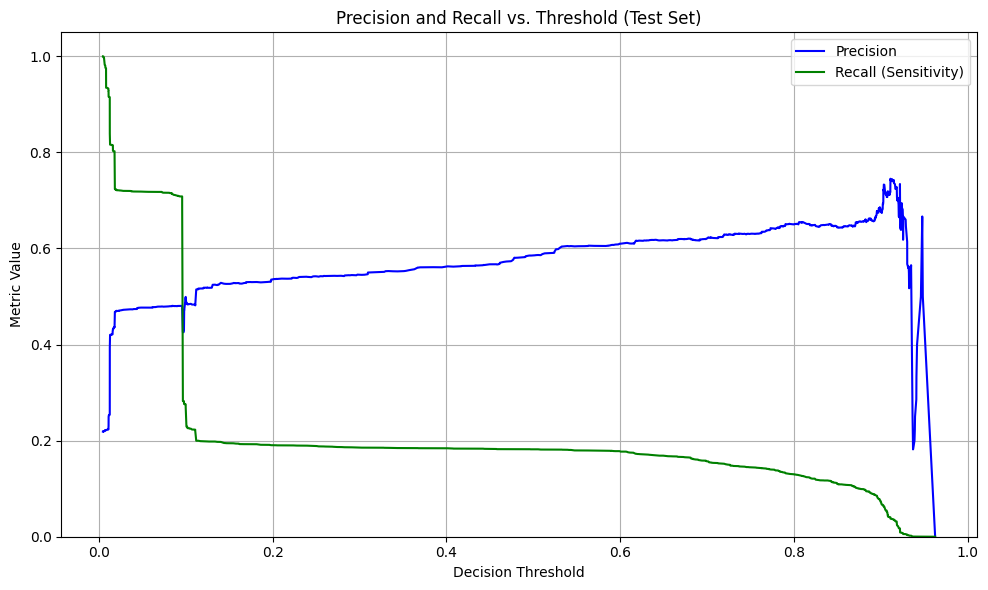

In [20]:
precision, recall, thresholds = precision_recall_curve(true_labels, probs)

# Plot
plt.figure(figsize=(10, 6))
plt.plot(thresholds, precision[:-1], label='Precision', color='blue')
plt.plot(thresholds, recall[:-1], label='Recall (Sensitivity)', color='green')
plt.xlabel('Decision Threshold')
plt.ylabel('Metric Value')
plt.title('Precision and Recall vs. Threshold (Test Set)')
plt.ylim(0, 1.05)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

O gráfico mostra como a precisão e a sensibilidade mudam de acordo com o valor de corte (threshold) usado pelo modelo.

* threshold baixo: o modelo classifica quase tudo como positivo. Isso faz com que a sensibilidade seja alta (encontra quase todos os casos positivos), mas a precisão seja baixa (muitos alsos positivos).

* threshold alto: o modelo só classifica como positivo quando está muito confiante. Isso faz com que a precisão aumente, mas a sensibilidade caia bastante, ou seja, ele deixa de identificar muitos casos positivos.

No contexto dos dados, como a oferta envolve um pequeno valor (até R$10), é interessante priorizar a sensibilidade, oferecendo ofertas dentro de uma margem de orçamento disponível. Por outro lado, para ofertas de valores maiores, é importante priorizar a precisão.


In [21]:
#  Compute F1-score for each threshold
f1_scores = 2 * (precision * recall) / (precision + recall + 1e-8)
best_threshold = thresholds[np.argmax(f1_scores)]

print(f"Best threshold based on F1-score: {best_threshold:.4f}")

#  Create new binary predictions based on the best threshold
pred_pd["prediction_thresholded"] = (pred_pd["prob_1"] >= best_threshold).astype(int)

# Generate a new classification report using the adjusted predictions
report_thresh = classification_report(
    y_true=pred_pd["label"],
    y_pred=pred_pd["prediction_thresholded"],
    digits=4
)

print("Classification Report using best threshold (based on F1-score):")
print(report_thresh)


Best threshold based on F1-score: 0.0722
Classification Report using best threshold (based on F1-score):
              precision    recall  f1-score   support

           0     0.9081    0.7816    0.8401     21617
           1     0.4794    0.7178    0.5748      6056

    accuracy                         0.7676     27673
   macro avg     0.6938    0.7497    0.7075     27673
weighted avg     0.8143    0.7676    0.7821     27673



O melhor threshold é 0.07, ideal para dados desbalanceados por equilibrar sensibilidade e precisão. O modelo tem boa acurácia (76,8%) e identifica bem quem aceita a oferta (71,8% de sensibilidade), embora com muitos falsos positivos (47,9% de precisão).

In [22]:
spark.stop()